# SWYNEX Task 1: Data Preparation (Titanic Dataset)

**Goal:** Take a raw public dataset, clean missing values, fix data types, and document every assumption.

**Dataset:** Titanic passenger data (891 rows, 12 columns), a public dataset widely used for data-science practice.
Source: [datasciencedojo/datasets](https://github.com/datasciencedojo/datasets/blob/master/titanic.csv), the same data as the Kaggle "Titanic: Machine Learning from Disaster" training set.

**Workflow**
1. Load and inspect the raw data
2. Identify the problems
3. Clean missing values
4. Fix data types and tidy text
5. Validate the result
6. Save `cleaned_data.csv`

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## 2. Load the raw data

In [2]:
df_raw = pd.read_csv("titanic_raw.csv")
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Inspect the raw data

In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


### 3.1 Missing values

In [5]:
missing = pd.DataFrame({
    "missing_count": df_raw.isnull().sum(),
    "missing_percent": (df_raw.isnull().mean() * 100).round(2),
})
missing[missing.missing_count > 0].sort_values("missing_percent", ascending=False)

,missing_count,missing_percent
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


### 3.2 Duplicates and suspicious values

In [6]:
print("Duplicate rows:", df_raw.duplicated().sum())
print("Duplicate PassengerId:", df_raw["PassengerId"].duplicated().sum())
print("Fare == 0 rows:", (df_raw["Fare"] == 0).sum())
print("Age range:", df_raw["Age"].min(), "to", df_raw["Age"].max())
print("Unique Sex values:", df_raw["Sex"].unique())
print("Unique Embarked values:", df_raw["Embarked"].unique())

Duplicate rows: 0
Duplicate PassengerId: 0
Fare == 0 rows: 15
Age range: 0.42 to 80.0
Unique Sex values: <StringArray>
['male', 'female']
Length: 2, dtype: str
Unique Embarked values: <StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str


## 4. Problems found

| # | Column | Problem | Severity |
|---|--------|---------|----------|
| 1 | `Cabin` | About 77% of values are missing | High |
| 2 | `Age` | About 20% of values are missing | Medium |
| 3 | `Embarked` | 2 values missing | Low |
| 4 | `Survived`, `Pclass`, `Sex`, `Embarked` | Stored as numbers or plain text instead of categories | Types |
| 5 | `Name`, `Ticket` | Text may carry stray whitespace | Tidiness |
| 6 | `Fare` | 15 rows with a fare of 0, and a few extreme high values | Review |
| 7 | Whole dataset | No duplicate rows, which is good | None |

## 5. Clean the data

In [7]:
df = df_raw.copy()   # keep the raw data untouched for before/after comparison

### 5.1 `Cabin`: keep the signal, then drop the column

**Assumption:** With ~77% missing, any imputation would be mostly invented. But *whether* a cabin was recorded may itself be informative
(cabins were mostly recorded for higher-class passengers), so I keep that as a `HasCabin` flag and drop the original column.

In [8]:
df["HasCabin"] = df["Cabin"].notnull().astype(int)
df = df.drop(columns=["Cabin"])
df[["HasCabin"]].value_counts()

HasCabin
0           687
1           204
Name: count, dtype: int64

### 5.2 `Age`: fill with the median of each passenger group

**Assumption:** Age is right-skewed, so the **median** is safer than the mean. Age also differs by class and sex,
so I fill using the median for each `Pclass` + `Sex` group instead of one global number. I also add an `AgeImputed` flag so anyone using the data later knows which ages are estimates.

In [9]:
df["AgeImputed"] = df["Age"].isnull().astype(int)

group_median = df.groupby(["Pclass", "Sex"])["Age"].transform("median")
df["Age"] = df["Age"].fillna(group_median)
df["Age"] = df["Age"].fillna(df["Age"].median())   # safety net if a group were entirely empty

print("Age missing after fill:", df["Age"].isnull().sum())

Age missing after fill: 0


### 5.3 `Embarked`: fill with the most common port

**Assumption:** Only 2 values are missing, so the **mode** is a low-risk fill.

In [10]:
mode_port = df["Embarked"].mode()[0]
print("Most common port:", mode_port)
df["Embarked"] = df["Embarked"].fillna(mode_port)

Most common port: S


### 5.4 Fix data types and tidy text

In [11]:
# Categories
for col in ["Survived", "Pclass", "Sex", "Embarked"]:
    df[col] = df[col].astype("category")

# Readable labels for the target column
df["Survived"] = df["Survived"].cat.rename_categories({0: "No", 1: "Yes"})

# Embarked codes to full names
df["Embarked"] = df["Embarked"].cat.rename_categories(
    {"C": "Cherbourg", "Q": "Queenstown", "S": "Southampton"}
)

# Text columns: strip whitespace and tidy spacing
df["Name"] = df["Name"].str.strip().str.replace(r"\s+", " ", regex=True)
df["Ticket"] = df["Ticket"].astype("string").str.strip()

# Integers and floats
df["Age"] = df["Age"].round(1)
df["Fare"] = pd.to_numeric(df["Fare"], errors="coerce").round(2)
for col in ["PassengerId", "SibSp", "Parch"]:
    df[col] = df[col].astype("int64")

df.dtypes

PassengerId       int64
Survived       category
Pclass         category
Name                str
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket           string
Fare            float64
Embarked       category
HasCabin          int64
AgeImputed        int64
dtype: object

### 5.5 Duplicates and unusual `Fare` values

**Assumptions:**
- No duplicate rows exist, but `drop_duplicates()` is run anyway as a safeguard.
- The 15 rows with `Fare = 0` are **kept**. They are plausibly crew, staff, or complimentary tickets rather than data errors, and removing them would throw away real records.
- Very high fares (over 500) are **kept** as genuine first-class tickets, not errors.

In [12]:
before = len(df)
df = df.drop_duplicates()
print("Rows removed as duplicates:", before - len(df))
print("Fare == 0 rows kept:", (df["Fare"] == 0).sum())
print("Fare > 500 rows kept:", (df["Fare"] > 500).sum())

Rows removed as duplicates: 0
Fare == 0 rows kept: 15
Fare > 500 rows kept: 3


## 6. Validate the cleaned data

In [13]:
comparison = pd.DataFrame({
    "missing_before": df_raw.isnull().sum(),
    "missing_after": df.isnull().sum().reindex(df_raw.columns),
})
comparison

,missing_before,missing_after
PassengerId,0,0.0
Survived,0,0.0
Pclass,0,0.0
Name,0,0.0
Sex,0,0.0
Age,177,0.0
SibSp,0,0.0
Parch,0,0.0
Ticket,0,0.0
Fare,0,0.0


In [14]:
print("Raw shape:    ", df_raw.shape)
print("Cleaned shape:", df.shape)
print("Total missing values after cleaning:", int(df.isnull().sum().sum()))
df.info()

Raw shape:     (891, 12)
Cleaned shape: (891, 13)
Total missing values after cleaning: 0
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    str     
 4   Sex          891 non-null    category
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    string  
 9   Fare         891 non-null    float64 
 10  Embarked     891 non-null    category
 11  HasCabin     891 non-null    int64   
 12  AgeImputed   891 non-null    int64   
dtypes: category(4), float64(2), int64(5), str(1), string(1)
memory usage: 66.3 KB


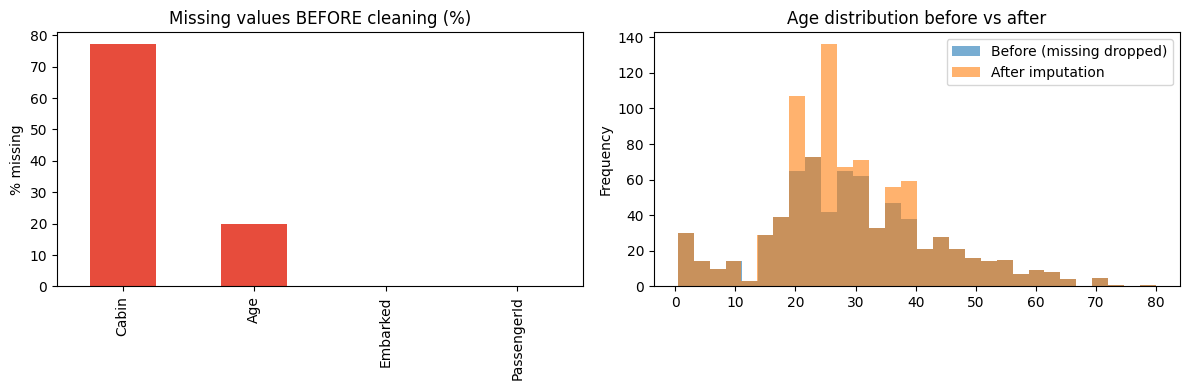

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

(df_raw.isnull().mean() * 100).sort_values(ascending=False).head(4).plot(
    kind="bar", ax=axes[0], color="#e74c3c")
axes[0].set_title("Missing values BEFORE cleaning (%)")
axes[0].set_ylabel("% missing")

df_raw["Age"].plot(kind="hist", bins=30, alpha=0.6, ax=axes[1], label="Before (missing dropped)")
df["Age"].astype(float).plot(kind="hist", bins=30, alpha=0.6, ax=axes[1], label="After imputation")
axes[1].set_title("Age distribution before vs after")
axes[1].legend()

plt.tight_layout()
plt.savefig("cleaning_summary.png", dpi=150)
plt.show()

In [16]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,HasCabin,AgeImputed
0,1,No,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,Southampton,0,0
1,2,Yes,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.28,Cherbourg,1,0
2,3,Yes,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.92,Southampton,0,0
3,4,Yes,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.10,Southampton,1,0
4,5,No,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,Southampton,0,0
5,6,No,3,"Moran, Mr. James",male,25.0,0,0,330877,8.46,Queenstown,0,1
6,7,No,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.86,Southampton,1,0
7,8,No,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.08,Southampton,0,0
8,9,Yes,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.13,Southampton,0,0
9,10,Yes,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.07,Cherbourg,0,0


## 7. Save the cleaned dataset

In [17]:
df.to_csv("cleaned_data.csv", index=False)
print("Saved cleaned_data.csv with", df.shape[0], "rows and", df.shape[1], "columns")

Saved cleaned_data.csv with 891 rows and 13 columns


## 8. Summary of assumptions

1. **Cabin (77% missing):** dropped. A `HasCabin` flag keeps the useful signal that a cabin was recorded.
2. **Age (~20% missing):** filled with the median for each `Pclass` + `Sex` group. Median is used because Age is skewed. An `AgeImputed` flag marks the estimated rows.
3. **Embarked (2 missing):** filled with the mode (Southampton).
4. **Data types:** `Survived`, `Pclass`, `Sex`, `Embarked` converted to categorical. Codes replaced with readable labels. Text columns stripped of extra whitespace.
5. **Fare = 0 and very high fares:** kept, since they look like real records rather than errors.
6. **Duplicates:** none found.
7. **Raw file is never modified.** All changes happen on a copy, and the result is saved separately.

## 9. Result

The raw data had missing values in 3 columns. The cleaned dataset has **0 missing values**, correct data types, and readable labels, and it is ready for exploratory analysis or modelling.